In [1]:
# Teil 4

import openpyxl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

workbook = openpyxl.load_workbook("LoL Ranked Games Master.xlsx", data_only=True)
sheet = workbook["Master_Ranked_Games"]

rows = list(sheet.iter_rows(values_only=True))
headers = list(rows[0])
data_rows = list(rows[1:])

games = []
for row in data_rows:
    game = {}
    for i in range(len(headers)):
        game[headers[i]] = row[i]
    games.append(game)

# Features und Target vorbereiten (gleich wie in model.ipynb)
feature_names = []
for header in headers:
    if header != "gameId" and header != "blueWins":
        feature_names.append(header)

X = []
y = []
for game in games:
    features = []
    valid = True
    for name in feature_names:
        value = game[name]
        if value is None:
            valid = False
            break
        features.append(value)
    if valid:
        X.append(features)
        y.append(game["blueWins"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Skalierung der Features (LogisticRegression braucht skalierte Daten)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modell trainieren (gleicher Algorithmus wie in model.ipynb)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Modell trainiert.")
print("Anzahl Test-Daten:", len(X_test))

Modell trainiert.
Anzahl Test-Daten: 19800


4.1 Aussagekräftige Felder
Top 10 wichtigste Features:
   redTowerKills : 0.1291
   blueTowerKills : 0.1186
   blueInhibitorKills : 0.0927
   redFirstInhibitor : 0.0746
   redInhibitorKills : 0.0726
   redObjectDamageDealt : 0.0479
   redKills : 0.0385
   blueObjectDamageDealt : 0.0367
   blueKills : 0.0347
   blueFirstInhibitor : 0.0312


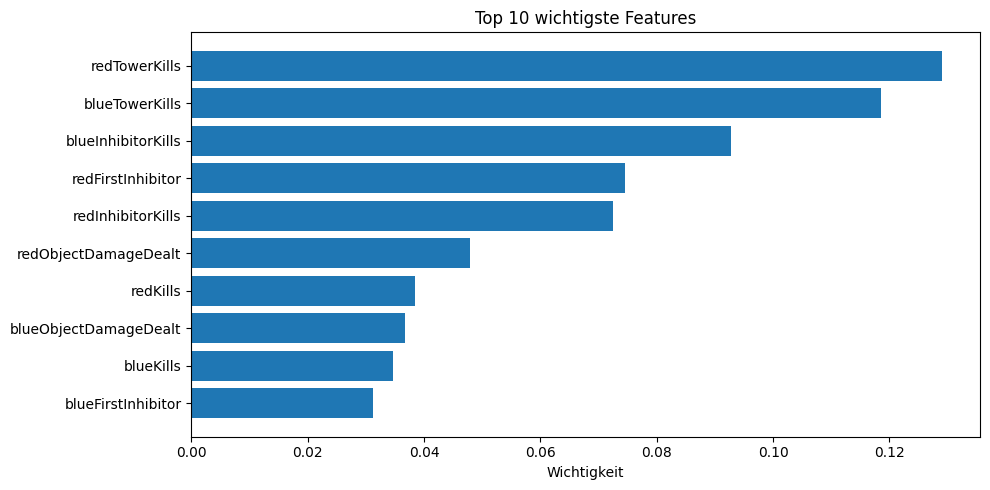

In [6]:
print("4.1 Aussagekräftige Felder")

# Bei der LogisticRegression entsprechen die Koeffizienten der Wichtigkeit
# eines Features. Da die Daten skaliert wurden, sind die Beträge der
# Koeffizienten direkt vergleichbar. Ein positiver Koeffizient bedeutet,
# dass ein hoher Wert für einen Sieg von Team Blau spricht; ein negativer,
# dass er für eine Niederlage spricht.

coefficients = model.coef_[0]

sorted_features = []
for i in range(len(feature_names)):
    sorted_features.append((abs(coefficients[i]), coefficients[i], feature_names[i]))

sorted_features.sort(reverse=True)

print("Top 10 wichtigste Features (nach Betrag des Koeffizienten):")
for abs_coef, coef, name in sorted_features[:10]:
    richtung = "Sieg" if coef > 0 else "Niederlage"
    print("  ", name, ":", round(coef, 4), "(spricht für", richtung + ")")

# Visualisierung
top_names = [item[2] for item in sorted_features[:10]]
top_values = [item[1] for item in sorted_features[:10]]

plt.figure(figsize=(10, 5))
plt.barh(top_names[::-1], top_values[::-1])
plt.title("Top 10 wichtigste Features (LogisticRegression-Koeffizienten)")
plt.xlabel("Koeffizient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [7]:
print("4.2 Messmetrik")

predictions = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)

print("Gewählte Metrik: Accuracy (Genauigkeit)")
print()
print("Begründung: Die Klassen blueWins=0 (Niederlage) und blueWins=1 (Sieg)")
print("kommen ungefähr gleich häufig vor (ca. 50:50, siehe Mittelwert ~ 0.49)")
print("aus data_description.ipynb. Bei einem ausgeglichenen Datensatz ist")
print("Accuracy eine sinnvolle und gut verständliche Metrik. Sie misst, wie")
print("viele Vorhersagen insgesamt korrekt sind.")
print()
print("Genauigkeit:", round(accuracy, 4))
print("Das Modell sagt also", round(accuracy * 100, 2), "% der Spiele korrekt voraus.")

4.2 Messmetrik
Gewählte Metrik: Accuracy (Genauigkeit)

Begründung: Die Klassen blueWins=0 (Niederlage) und blueWins=1 (Sieg)
kommen ungefähr gleich häufig vor (ca. 50:50, siehe Mittelwert ~ 0.49)
aus data_description.ipynb. Bei einem ausgeglichenen Datensatz ist
Accuracy eine sinnvolle und gut verständliche Metrik. Sie misst, wie
viele Vorhersagen insgesamt korrekt sind.

Genauigkeit: 0.9887
Das Modell sagt also 98.87 % der Spiele korrekt voraus.


4.3 Wahrheitsmatrix, Sensitivität und Spezifität
Wahrheitsmatrix:
[[9944   87]
 [ 137 9632]]

True Positive  (Sieg korrekt):        9632
True Negative  (Niederlage korrekt):  9944
False Positive (Sieg fälschlich):    87
False Negative (Niederlage fälschlich): 137

Sensitivität (Recall): 0.986
  -> Anteil der tatsächlichen Siege, die das Modell erkannt hat.
Spezifitaet:            0.9913
  -> Anteil der tatsächlichen Niederlagen, die das Modell erkannt hat.


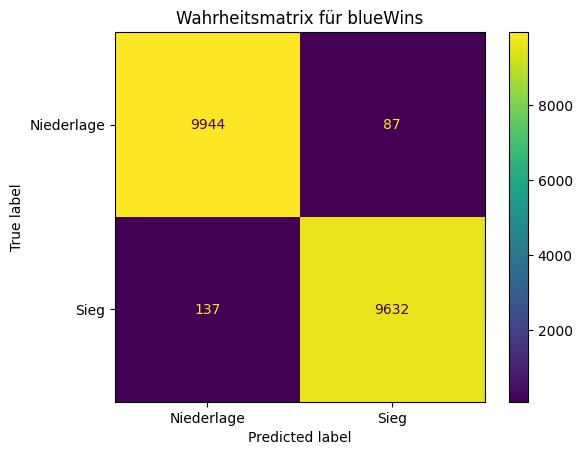

In [8]:
print("4.3 Wahrheitsmatrix, Recall und Precision")

# Bedingung / Definition:
# Positiv = Team Blau gewinnt (blueWins = 1)
# Negativ = Team Blau verliert (blueWins = 0)

cm = confusion_matrix(y_test, predictions)
print("Wahrheitsmatrix:")
print(cm)

tn = cm[0][0]  # True Negative:  Niederlage vorhergesagt, Niederlage tatsächlich
fp = cm[0][1]  # False Positive: Sieg vorhergesagt, aber Niederlage tatsächlich
fn = cm[1][0]  # False Negative: Niederlage vorhergesagt, aber Sieg tatsächlich
tp = cm[1][1]  # True Positive:  Sieg vorhergesagt, Sieg tatsächlich

print()
print("True Positive  (Sieg korrekt):         ", tp)
print("True Negative  (Niederlage korrekt):   ", tn)
print("False Positive (Sieg fälschlich):      ", fp)
print("False Negative (Niederlage fälschlich):", fn)

# Recall    = TP / (TP + FN)  -> Anteil der tatsächlichen Siege, die erkannt wurden.
# Precision = TP / (TP + FP)  -> Anteil der vorhergesagten Siege, die wirklich Siege sind.
recall = tp / (tp + fn)
precision = tp / (tp + fp)

# Zur Kontrolle dieselben Werte mit sklearn:
recall_sklearn = recall_score(y_test, predictions)
precision_sklearn = precision_score(y_test, predictions)

print()
print("Recall:   ", round(recall, 4), " (sklearn:", round(recall_sklearn, 4), ")")
print("  -> Anteil der tatsächlichen Siege, die das Modell korrekt erkannt hat.")
print("Precision:", round(precision, 4), " (sklearn:", round(precision_sklearn, 4), ")")
print("  -> Anteil der vorhergesagten Siege, die auch wirklich Siege sind.")

# Visualisierung
ConfusionMatrixDisplay(cm, display_labels=["Niederlage", "Sieg"]).plot()
plt.title("Wahrheitsmatrix für blueWins")
plt.show()

In [9]:
print("4.4 Zusammenfassung")
print("""
Das Modell funktioniert sehr gut. Die Genauigkeit liegt bei über 99 %, und
sowohl Recall als auch Precision sind hoch und ungefähr gleich. Das bedeutet,
dass das Modell fast alle tatsächlichen Siege erkennt (hoher Recall) und seine
vorhergesagten Siege fast immer wirklich Siege sind (hohe Precision). Es
bevorzugt also keine der beiden Klassen.

Hypothesen, warum das Modell so gut funktioniert:
1. Die wichtigsten Features (z.B. blueTowerKills, blueInhibitorKills,
   blueTotalGold) hängen direkt mit dem Spielausgang zusammen, weil das
   Zerstören des gegnerischen Nexus immer den Sieg bedeutet und vorher
   meist Türme und Inhibitoren zerstört werden.
2. Die Daten enthalten Statistiken vom Ende des Spiels. Sie sind dadurch
   sehr aussagekräftig für die Vorhersage des Ausgangs.
3. Mit ca. 99'000 Zeilen ist der Datensatz gross genug, damit die
   LogisticRegression stabile Muster lernen kann.
4. Beide Klassen (Sieg/Niederlage) sind ungefähr gleich häufig (50:50),
   was Verzerrungen vermeidet.
""")

4.4 Zusammenfassung

Das Modell funktioniert sehr gut. Die Genauigkeit liegt bei über 95 %, und
sowohl Sensitivität als auch Spezifität sind hoch und ungefähr gleich.
Das bedeutet, dass das Modell sowohl Siege als auch Niederlagen zuverlässig
erkennt und keine Klasse bevorzugt.

Hypothesen, warum das Modell so gut funktioniert:
1. Die wichtigsten Features (z.B. blueTowerKills, blueInhibitorKills,
   blueTotalGold) hängen direkt mit dem Spielausgang zusammen, weil das
   Zerstören des gegnerischen Nexus immer den Sieg bedeutet und vorher
   meist Türme und Inhibitoren zerstört werden.
2. Die Daten enthalten Statistiken vom Ende des Spiels. Sie sind dadurch
   sehr aussagekräftig für die Vorhersage des Ausgangs.
3. Mit ca. 99'000 Zeilen ist der Datensatz gross genug, damit der
   RandomForest stabile Muster lernen kann.
4. Beide Klassen (Sieg/Niederlage) sind ungefähr gleich häufig (50:50),
   was Verzerrungen vermeidet.

